ORIGINAL DECK

Ace of Hearts      2 of Hearts        3 of Hearts        4 of Hearts        
5 of Hearts        6 of Hearts        7 of Hearts        8 of Hearts        
9 of Hearts        10 of Hearts       Jack of Hearts     Queen of Hearts    
King of Hearts     Ace of Diamonds    2 of Diamonds      3 of Diamonds      
4 of Diamonds      5 of Diamonds      6 of Diamonds      7 of Diamonds      
8 of Diamonds      9 of Diamonds      10 of Diamonds     Jack of Diamonds   
Queen of Diamonds  King of Diamonds   Ace of Clubs       2 of Clubs         
3 of Clubs         4 of Clubs         5 of Clubs         6 of Clubs         
7 of Clubs         8 of Clubs         9 of Clubs         10 of Clubs        
Jack of Clubs      Queen of Clubs     King of Clubs      Ace of Spades      
2 of Spades        3 of Spades        4 of Spades        5 of Spades        
6 of Spades        7 of Spades        8 of Spades        9 of Spades        
10 of Spades       Jack of Spades     Queen of Spades    King

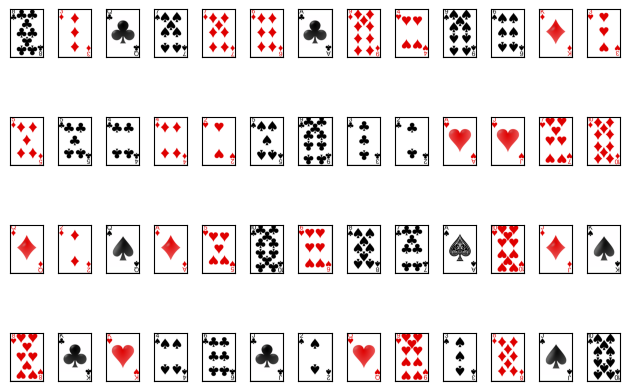

In [4]:
import random
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

class Card:
    FACES = ['Ace', '2', '3', '4', '5', '6','7', '8', '9', '10', 'Jack', 'Queen', 'King']
    SUITS = ['Hearts', 'Diamonds', 'Clubs', 'Spades']

    def __init__(self, face, suit):
        self._face = face
        self._suit = suit

    @property
    def face(self):
        return self._face

    @property
    def suit(self):
        return self._suit

    @property
    def image_name(self):
        return str(self).replace(' ', '_').lower() + '.png'

    def __repr__(self):
        return f"Card(face='{self.face}', suit='{self.suit}')"

    def __str__(self):
        return f"{self.face} of {self.suit}"

    def __format__(self, format_spec):
        return f"{str(self):{format_spec}}"


class DeckOfCards:
    NUMBER_OF_CARDS = 52

    def __init__(self):
        self._current_card = 0
        self._deck = []

        for count in range(DeckOfCards.NUMBER_OF_CARDS):
            self._deck.append(
                Card(Card.FACES[count % 13],
                     Card.SUITS[count // 13])
            )

    def shuffle(self):
        self._current_card = 0
        random.shuffle(self._deck)

    def deal_card(self):
        try:
            card = self._deck[self._current_card]
            self._current_card += 1
            return card
        except IndexError:
            return None

    def __str__(self):
        s = ''
        for index, card in enumerate(self._deck):
            s += f"{card:<19}"
            if (index + 1) % 4 == 0:
                s += '\n'
        return s


if __name__ == "__main__":
    deck_of_cards = DeckOfCards()
    print("ORIGINAL DECK\n")
    print(deck_of_cards)

    deck_of_cards.shuffle()
    print("\nSHUFFLED DECK\n")
    print(deck_of_cards)

    print("\nDEALING 5 CARDS")
    for _ in range(5):
        print(deck_of_cards.deal_card())

    try:
        print("\nDisplaying card images...")
        deck_of_cards.shuffle()
        path = Path('.').joinpath('cards')
        figure, axes_list = plt.subplots(nrows=4, ncols=13)

        for axes in axes_list.ravel():
            axes.get_xaxis().set_visible(False)
            axes.get_yaxis().set_visible(False)

            card = deck_of_cards.deal_card()
            image_name = card.image_name
            img = mpimg.imread(str(path.joinpath(image_name).resolve()))
            axes.imshow(img)

        figure.tight_layout()
        plt.show()

    except Exception as e:
        print("\nImage display skipped (card_images folder not found).")
        print("Error:", e)